# Data Science for Business - Fair ML for Credit Scoring


## Initialize notebook
Load required packages.

In [1]:
# Install packages that are not already installed on Colab
# !pip install aif360

In [2]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

from aif360.sklearn.datasets import fetch_german
from aif360.sklearn.metrics import disparate_impact_ratio, equal_opportunity_difference
from aif360.sklearn.preprocessing import Reweighing
from aif360.sklearn.postprocessing import RejectOptionClassifier, RejectOptionClassifierCV


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'
pip install 'aif360[OptimalTransport]'
pip install 'aif360[FairAdapt]'


## Problem description

In this notebook we will explore fairness in machine learning models for credit scoring using the German Credit dataset (https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data). The goal is to predict whether an individual has good or bad credit risk while ensuring that the model does not discriminate based on sensitive attributes such as gender or age.


## Load data

First, we load the German Credit data from the AIF360 package. For more information, see: https://aif360.readthedocs.io/en/stable/modules/generated/aif360.sklearn.datasets.fetch_german.html

In [3]:
data = fetch_german(numeric_only=True)

In [4]:
data

Dataset(X=                        duration  credit_amount  installment_commitment  \
sex age foreign_worker                                                    
1   1   1                      6           1169                       4   
0   0   1                     48           5951                       2   
1   1   1                     12           2096                       2   
        1                     42           7882                       2   
        1                     24           4870                       3   
...                          ...            ...                     ...   
0   1   1                     12           1736                       3   
1   1   1                     30           3857                       4   
        1                     12            804                       4   
    0   1                     45           1845                       4   
    1   1                     45           4576                       3   

              

In [5]:
data.X

duration  credit_amount  installment_commitment  \
sex age foreign_worker                                                    
1   1   1                      6           1169                       4   
0   0   1                     48           5951                       2   
1   1   1                     12           2096                       2   
        1                     42           7882                       2   
        1                     24           4870                       3   
...                          ...            ...                     ...   
0   1   1                     12           1736                       3   
1   1   1                     30           3857                       4   
        1                     12            804                       4   
    0   1                     45           1845                       4   
    1   1                     45           4576                       3   

                        residence_since  age  existing_credits  \
sex age foreign_worker                                           
1   1   1                             4   67                 2   
0   0   1                             2   22                 1   
1   1   1                             3   49                 1   
        1                             4   45                 1   
        1                             4   53                 2   
...                                 ...  ...               ...   
0   1   1                             4   31                 1   
1   1   1                             4   40                 1   
        1                             4   38                 1   
    0   1                             4   23                 1   
    1   1                             4   27                 1   

                        num_dependents  foreign_worker  sex  
sex age foreign_worker                                       
1   1   1                            1               1    1  
0   0   1                            1               1    0  
1   1   1                            2               1    1  
        1                            2               1    1  
        1                            2               1    1  
...                                ...             ...  ...  
0   1   1                            1               1    0  
1   1   1                            1               1    1  
        1                            1               1    1  
    0   1                            1               1    1  
    1   1                            1               1    1  

[1000 rows x 9 columns]

In [6]:
data.y

sex  age  foreign_worker
1    1    1                 1
0    0    1                 0
1    1    1                 1
          1                 1
          1                 0
                           ..
0    1    1                 1
1    1    1                 1
          1                 1
     0    1                 0
     1    1                 1
Name: credit-risk, Length: 1000, dtype: int64

## Train classifier

Next, we train a standard classifier using sklearn without any fairness constraints.

In [7]:
X_train = data.X[:800]
y_train = data.y[:800]

X_test = data.X[800:]
y_test = data.y[800:]

In [8]:
classifier_logit = LogisticRegression().fit(X_train, y_train)

In [9]:
y_pred = classifier_logit.predict(X_test)
y_proba = classifier_logit.predict_proba(X_test)

In [10]:
f1_score(y_test, y_pred)

0.8267477203647416

## Compute fairness metrics

### Equal Opportunity Difference

Here we compute the Equal Opportunity Difference metric before applying any fairness mitigation techniques. The negative value indicates implies higher benefit for the privileged group. However, the value is relatively close to zero, indicating only a small disparity between groups.

-0.04128205128205131


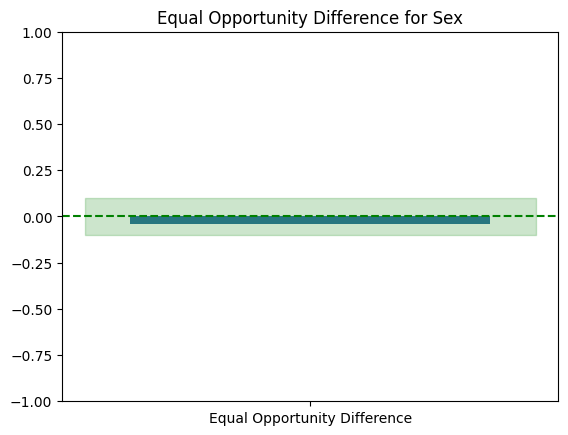

In [11]:
eod = equal_opportunity_difference(y_test, y_pred, prot_attr='sex', priv_group=1)
print(eod)

sns.barplot(x=['Equal Opportunity Difference'], y=[eod])
plt.axhline(y=0.0, color='green', linestyle='--')
plt.fill_between(x=[-0.5, 0.5], y1=-0.1, y2=0.1, color='green', alpha=0.2)
plt.title('Equal Opportunity Difference for Sex')
plt.ylim(-1.0, 1.0)
plt.show()

### Disparate Impact Ratio

Similarly, we compute the Disparate Impact Ratio metric. Again, the value less than 1 indicates implies higher benefit for the privileged group. However, the value is within the bounds of the "four-fifths rule" (i.e., between 0.8 and 1.25), suggesting that the disparity is not substantial.

0.9672988881621974


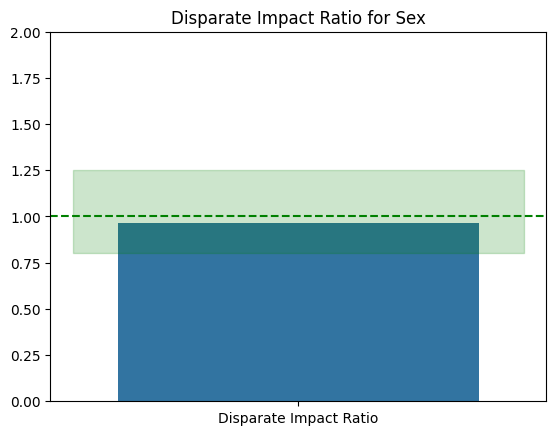

In [12]:
di = disparate_impact_ratio(y_test, y_pred, prot_attr='sex', priv_group=1)
print(di)

sns.barplot(x=['Disparate Impact Ratio'], y=[di])
plt.axhline(y=1.0, color='green', linestyle='--')
plt.fill_between(x=[-0.5, 0.5], y1=0.8, y2=1.25, color='green', alpha=0.2)
plt.title('Disparate Impact Ratio for Sex')
plt.ylim(0, 2)
plt.show()

## Bias mitigation algorithms

Altough the fairness metrics indicate only a small disparity, we will still apply two common bias mitigation techniques to see their effect on fairness and accuracy.

### Pre-processing algorithms: Reweighing

In [13]:
rw_preprocessor = Reweighing(prot_attr='sex')
new_weights = rw_preprocessor.fit_transform(X_train, y_train)

Display the the weights assigned to each training observation.

In [14]:
new_weights

(                        duration  credit_amount  installment_commitment  \
 sex age foreign_worker                                                    
 1   1   1                      6           1169                       4   
 0   0   1                     48           5951                       2   
 1   1   1                     12           2096                       2   
         1                     42           7882                       2   
         1                     24           4870                       3   
 ...                          ...            ...                     ...   
 0   0   1                      9           2301                       2   
 1   1   1                     18           7511                       1   
 0   0   1                     12           1258                       2   
 1   1   1                     24            717                       4   
         1                      9           1549                       4   
 
          

Retrain the classifier using the computed sample weights.

In [15]:
classifier_logit_rw = LogisticRegression().fit(X_train, y_train, sample_weight=new_weights[1])

In [16]:
y_pred_rw = classifier_logit_rw.predict(X_test)

Compute the Equal Opportunity Difference and Disparate Impact Ratio metrics after applying the Reweighing techniques. In both cases we now see higher benefit for the unprivileged group (i.e., EOD larger than 0 and DIR larger than 1).

0.040000000000000036


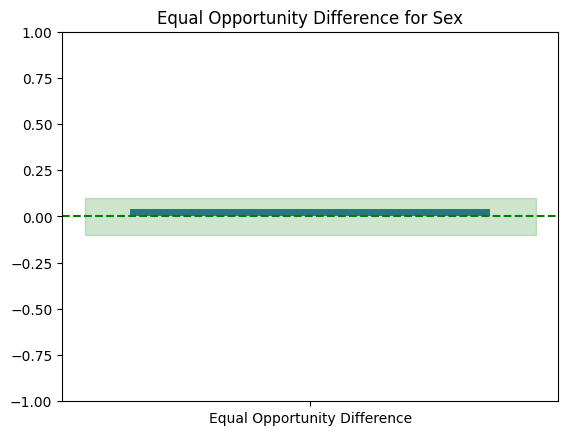

In [17]:
eod_rw = equal_opportunity_difference(y_test, y_pred_rw, prot_attr='sex', priv_group=1)
print(eod_rw)

sns.barplot(x=['Equal Opportunity Difference'], y=[eod_rw])
plt.axhline(y=0.0, color='green', linestyle='--')
plt.fill_between(x=[-0.5, 0.5], y1=-0.1, y2=0.1, color='green', alpha=0.2)
plt.title('Equal Opportunity Difference for Sex')
plt.ylim(-1.0, 1.0)
plt.show()


1.050580997949419


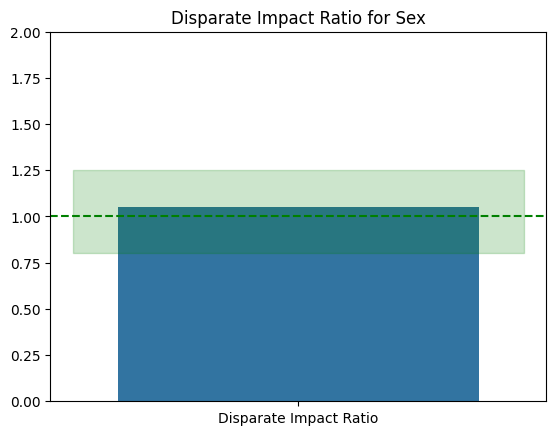

In [18]:
di_rw = disparate_impact_ratio(y_test, y_pred_rw, prot_attr='sex', priv_group=1)
print(di_rw)

sns.barplot(x=['Disparate Impact Ratio'], y=[di_rw])
plt.axhline(y=1.0, color='green', linestyle='--')
plt.fill_between(x=[-0.5, 0.5], y1=0.8, y2=1.25, color='green', alpha=0.2)
plt.title('Disparate Impact Ratio for Sex')
plt.ylim(0, 2)
plt.show()

Surprisingly, the accuracy has even improved after applying the Reweighing technique.

In [19]:
f1_score(y_test, y_pred_rw)

0.8307692307692308

### Post-processing algorithms: Reject Option Classification

For ROC, we need to choose the margin in which we want to change the labels. Here, we choose a margin of 0.02 around the decision boundary (i.e., 0.5).

In [39]:
roc_postprocessor = RejectOptionClassifier(prot_attr='sex', threshold=0.5, margin=0.02)

As ROC is a post-processing technique, we do not need to retrain the classifier. Instead, we directly apply ROC to the predictions of the original classifier.

In [40]:
roc_postprocessor.fit(X_train, y_train)

RejectOptionClassifier(margin=0.02, prot_attr='sex')

In [41]:
y_preds_roc = roc_postprocessor.predict(pd.DataFrame(y_proba, index=y_test.index))

Check fairness metrics after Reject Option Classification. Again, we see higher benefit for the unprivileged group after bias mitigation. And compared to Reweighing, ROC procuded more fair results (i.e., EOD closer to 0 and DIR closer to 1).

0.014358974358974375


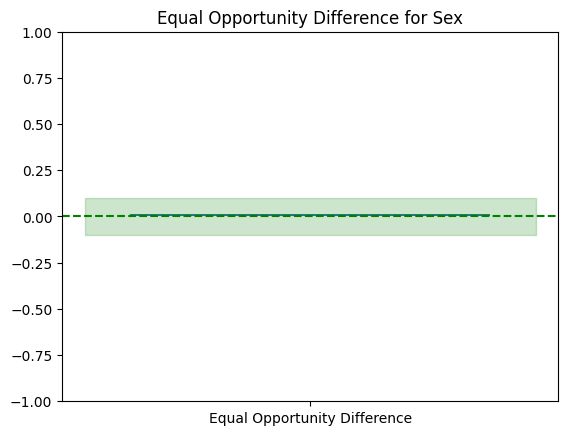

In [42]:
eod_roc = equal_opportunity_difference(y_test, y_preds_roc, prot_attr='sex', priv_group=1)
print(eod_roc)

sns.barplot(x=['Equal Opportunity Difference'], y=[eod_roc])
plt.axhline(y=0.0, color='green', linestyle='--')
plt.fill_between(x=[-0.5, 0.5], y1=-0.1, y2=0.1, color='green', alpha=0.2)
plt.title('Equal Opportunity Difference for Sex')
plt.ylim(-1.0, 1.0)
plt.show()


1.023066485753053


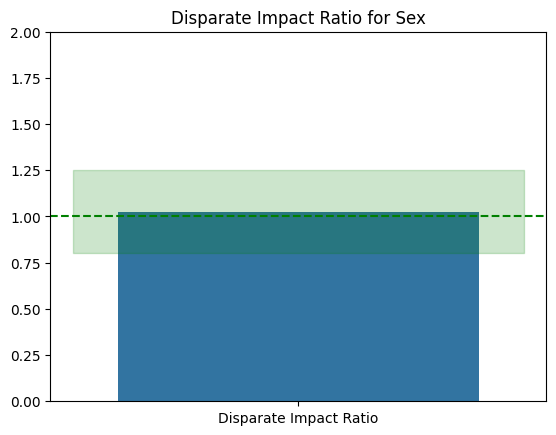

In [43]:
di_roc = disparate_impact_ratio(y_test, y_preds_roc, prot_attr='sex', priv_group=1)
print(di_roc)

sns.barplot(x=['Disparate Impact Ratio'], y=[di_roc])
plt.axhline(y=1.0, color='green', linestyle='--')
plt.fill_between(x=[-0.5, 0.5], y1=0.8, y2=1.25, color='green', alpha=0.2)
plt.title('Disparate Impact Ratio for Sex')
plt.ylim(0, 2)
plt.show()

And the accuracy did not change much compared to the original classifier.

In [44]:
f1_score(y_test, y_preds_roc)

0.8246153846153846